# Computer Exercise 15.16 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — Chapter 15 확장 사례연구
> **단원**: §15.16 Distributional RL — *Dueling C51 (categorical value distribution)*
> **풀이 일자**: Day 83
> **언어**: Python 3 (NumPy / pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Replace the scalar-Q dueling head with a **categorical (C51)** distributional head:
> represent the return distribution as $N$ atoms $\{z_i\}$ on $[V_\min, V_\max]$, and train
> with the projected categorical Bellman operator. Compare *Dueling-scalar-Q* vs *Dueling-C51*
> on MountainCar-lite under identical Double-DQN stabilizers. Analyze the two axes — mean
> return and seed-variance — that Day 82 identified as distinct sources of the
> "reproducibility gain".

### 한국어 풀이용 정리
Day 82 (§15.15) 은 dueling head 의 $V$/$A$ 분해가 **mean-neutral** 이면서 시드편차를
2.4–2.8× 압축하는 재현성 이득을 보인다는 관찰을 정량화했다. §15.16 은 head 의 다른
확장 — **표적을 스칼라 Q 대신 카테고리 분포** — 를 도입해 (i) 확률 표적이 편향과 분산에
어떻게 영향을 미치는지, (ii) 표본 효율은 개선되는지, (iii) 시드편차 축의 이득이 유지·확대·축소되는지
격리 조건에서 실측한다.


## 2. 수학적 배경

### 2.1 카테고리 분포 $Z(s,a)$ (Bellemare et al. 2017, C51)

Return 을 확률변수 $Z(s,a) = \sum_{k \ge 0} \gamma^k R_{t+k}$ 로 보고, 유한 개 원자
$\{z_i\}_{i=0}^{N-1}$, $z_i = V_\min + i\,\Delta z$, $\Delta z = (V_\max - V_\min)/(N-1)$
위에 확률 $p_i(s,a) \ge 0$, $\sum_i p_i = 1$ 를 두면 스칼라

$$Q(s,a) = \sum_i z_i \, p_i(s,a).$$

### 2.2 분포 Bellman 백업 & 사영

$$
(\mathcal T Z)(s,a) \overset d = R + \gamma Z(S', A^\ast(S')), \qquad
A^\ast(s') = \arg\max_{a'} \sum_i z_i \, p_i(s', a').
$$

$\mathcal T Z$ 의 지지집합은 $\{r + \gamma z_i\}$ 로 이동하므로 원 지지집합 밖에 놓일 수
있다. 이를 원자 위로 **사영(projection)** $\Pi$:

$$
(\Pi \mathcal T Z)_i \;=\; \sum_j p_j \cdot \operatorname{tri}\!\left(\tfrac{[r+\gamma z_j]_{V_\min}^{V_\max} - z_i}{\Delta z}\right),
$$

로 옮긴 뒤 KL divergence $\mathrm{KL}(\Pi \mathcal T Z \,\|\, Z_\theta)$ 로 온라인 분포와
정합. 손실은

$$
L(\theta) \;=\; -\sum_i m_i \log p_i(s,a^\ast_{\text{taken}}),\qquad m = \Pi \mathcal T Z.
$$

### 2.3 Dueling C51

Head 를 $V$-logits $\ell^V(z)$ 와 $A$-logits $\ell^A(a, z)$ 로 나누어

$$
L(a,z) = \ell^V(z) + \big(\ell^A(a,z) - \tfrac1{|\mathcal A|}\textstyle\sum_{a'} \ell^A(a',z)\big),\qquad
p_a(z) = \operatorname{softmax}_z L(a,z).
$$

Mean-subtraction 은 스칼라-dueling 과 동일한 이유 — $V \leftrightarrow A$ 자유도 제거 — 로
필요.

### 2.4 스칼라 vs 카테고리의 표적 차이

* **스칼라 Q-learning**: $y = r + \gamma \max_{a'} Q(s', a')$, MSE 손실 → **점 표적**.
* **C51**: $m = \Pi \mathcal T Z$, KL 손실 → **분포 표적**.

동일한 시드·환경·stabilizer 조건에서 이 차이가 mean/std 축으로 어떻게 나타나는지가
격리 실험의 핵심.


## 3. 풀이 흐름

1. **공통 세팅**: MountainCar-lite (`force=0.005`, `max_steps=120`), MLP $2\to16\to$head,
   batch=8, buffer=800, target sync 25, clip=10, Double DQN.
2. **조건 A (Dueling-scalar-Q)**: 스칼라 dueling head, MSE 손실.
3. **조건 B (Dueling-C51)**: $N=11$ 원자, $[V_\min,V_\max]=[-15, 0]$, KL 손실.
4. **학습**: 2 시드 (9101, 9102) × 12 에피소드.
5. **표 & 그래프**: tail-5 mean/std, 학습 곡선, 시드편차 요약.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import deque
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

# =====================================================================
# 1) shared_core (embedded) — MountainCar-lite, MLP, dueling heads, PER buffer
# =====================================================================
# Shared core for Day 83 §15.16 — Distributional (C51) + Noisy Nets on Dueling
import numpy as np
from collections import deque

class MountainCarLite:
    def __init__(self, force=0.005, max_steps=200, seed=0):
        self.force = force; self.max_steps = max_steps
        self.rng = np.random.RandomState(seed)
    def reset(self):
        self.x = self.rng.uniform(-0.6, -0.4); self.v = 0.0; self.t = 0
        return np.array([self.x, self.v], dtype=np.float64)
    def step(self, a):
        f = (a - 1) * self.force
        self.v += f + (-0.0025) * np.cos(3.0 * self.x)
        self.v = np.clip(self.v, -0.07, 0.07)
        self.x += self.v
        if self.x < -1.2: self.x = -1.2; self.v = 0.0
        self.t += 1
        goal = self.x >= 0.5
        done = goal or (self.t >= self.max_steps)
        return np.array([self.x, self.v], dtype=np.float64), (0.0 if goal else -1.0), done

def he(shape, rng):
    return rng.randn(*shape).astype(np.float64) * np.sqrt(2.0 / shape[0])
def relu(x): return np.maximum(x, 0.0)

# ---------- baseline dueling ----------
class DuelingMLP:
    def __init__(self, nS=2, H=16, nA=3, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = he((nS, H), rng); self.b1 = np.zeros(H)
        self.Wv = he((H, 1), rng);  self.bv = np.zeros(1)
        self.Wa = he((H, nA), rng); self.ba = np.zeros(nA)
        self.nA = nA
    def forward(self, s):
        h = relu(s @ self.W1 + self.b1)
        v = h @ self.Wv + self.bv
        a = h @ self.Wa + self.ba
        q = v + (a - a.mean(axis=-1, keepdims=True))
        return q, h, v, a
    def copy_from(self, o):
        for k in ('W1','b1','Wv','bv','Wa','ba'):
            setattr(self, k, getattr(o, k).copy())

# ---------- Dueling C51 ----------
class DuelingC51:
    def __init__(self, nS=2, H=16, nA=3, N=21, vmin=-20.0, vmax=0.0, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = he((nS, H), rng); self.b1 = np.zeros(H)
        self.Wv = he((H, N), rng);  self.bv = np.zeros(N)
        self.Wa = he((H, nA*N), rng); self.ba = np.zeros(nA*N)
        self.nA = nA; self.N = N
        self.z = np.linspace(vmin, vmax, N)
        self.vmin=vmin; self.vmax=vmax; self.dz=(vmax-vmin)/(N-1)
    def forward(self, s):
        h = relu(s @ self.W1 + self.b1)
        v_log = h @ self.Wv + self.bv
        a_log = (h @ self.Wa + self.ba).reshape(self.nA, self.N)
        L = v_log[None,:] + (a_log - a_log.mean(axis=0, keepdims=True))
        L = L - L.max(axis=-1, keepdims=True)
        p = np.exp(L); p /= p.sum(axis=-1, keepdims=True)
        q = (p * self.z).sum(axis=-1)
        return q, p, h, v_log, a_log
    def copy_from(self, o):
        for k in ('W1','b1','Wv','bv','Wa','ba'):
            setattr(self, k, getattr(o, k).copy())

# ---------- Noisy linear ----------
def _f(x): return np.sign(x) * np.sqrt(np.abs(x))
class NoisyLinear:
    def __init__(self, nin, nout, sigma0=0.5, rng=None):
        rng = rng or np.random.RandomState(0)
        mr = 1.0/np.sqrt(nin)
        self.mu_w = rng.uniform(-mr, mr, size=(nin, nout))
        self.mu_b = rng.uniform(-mr, mr, size=(nout,))
        self.sig_w = np.full((nin, nout), sigma0/np.sqrt(nin))
        self.sig_b = np.full((nout,),     sigma0/np.sqrt(nin))
        self.nin, self.nout = nin, nout
        self._rng = rng
        self.eps_in = np.zeros(nin); self.eps_out = np.zeros(nout)
    def resample(self):
        self.eps_in  = _f(self._rng.randn(self.nin))
        self.eps_out = _f(self._rng.randn(self.nout))
    def forward(self, x, sample=True):
        if sample:
            eps_w = np.outer(self.eps_in, self.eps_out)
            W = self.mu_w + self.sig_w * eps_w
            b = self.mu_b + self.sig_b * self.eps_out
        else:
            W = self.mu_w; b = self.mu_b
        return x @ W + b

# ---------- Dueling Noisy MLP ----------
class DuelingNoisyMLP:
    def __init__(self, nS=2, H=16, nA=3, sigma0=0.5, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = he((nS, H), rng); self.b1 = np.zeros(H)
        self.noisy_v = NoisyLinear(H, 1,  sigma0=sigma0, rng=np.random.RandomState(seed+100))
        self.noisy_a = NoisyLinear(H, nA, sigma0=sigma0, rng=np.random.RandomState(seed+200))
        self.nA = nA
    def resample_noise(self):
        self.noisy_v.resample(); self.noisy_a.resample()
    def forward(self, s, sample=True):
        h = relu(s @ self.W1 + self.b1)
        v = self.noisy_v.forward(h, sample=sample)
        a = self.noisy_a.forward(h, sample=sample)
        q = v + (a - a.mean(axis=-1, keepdims=True))
        return q, h, v, a
    def copy_from(self, o):
        for k in ('W1','b1'):
            setattr(self, k, getattr(o, k).copy())
        for tgt, src in [(self.noisy_v, o.noisy_v), (self.noisy_a, o.noisy_a)]:
            tgt.mu_w = src.mu_w.copy(); tgt.mu_b = src.mu_b.copy()
            tgt.sig_w = src.sig_w.copy(); tgt.sig_b = src.sig_b.copy()

# ---------- PER buffer ----------
class PERBuffer:
    def __init__(self, cap=2000, alpha=0.6):
        self.cap, self.alpha = cap, alpha
        self.data = [None]*cap
        self.pri  = np.zeros(cap)
        self.ptr, self.size = 0, 0
        self.max_pri = 1.0
    def push(self, tr):
        self.data[self.ptr] = tr
        self.pri[self.ptr] = self.max_pri
        self.ptr = (self.ptr + 1) % self.cap
        self.size = min(self.size + 1, self.cap)
    def sample(self, B, beta, rng):
        pri = self.pri[:self.size] ** self.alpha
        P = pri / pri.sum()
        idx = rng.choice(self.size, size=B, p=P)
        w = (self.size * P[idx]) ** (-beta); w = w / w.max()
        batch = [self.data[i] for i in idx]
        return batch, idx, w
    def update_pri(self, idx, td):
        p = np.abs(td) + 1e-6
        self.pri[idx] = p
        self.max_pri = max(self.max_pri, float(p.max()))


# =====================================================================
# 2) trainers (embedded) — Double-DQN / n-step / PER / C51 / Noisy 통합 학습 루프
# =====================================================================
"""Training loops for Day 83 problems (optimized)."""
import numpy as np
from collections import deque

def _softmax(L, axis=-1):
    L = L - L.max(axis=axis, keepdims=True); e = np.exp(L)
    return e / e.sum(axis=axis, keepdims=True)

def _project_c51_single(r, d, next_p, gamma, z, vmin, vmax, dz):
    """Vectorized projection for single sample.  next_p: (N,)."""
    N = z.shape[0]
    if d:
        # terminal → target is delta at 0
        m = np.zeros(N)
        j = int(np.clip((0 - vmin)/dz, 0, N-1))
        m[j] = 1.0
        return m
    Tz = np.clip(r + gamma * z, vmin, vmax)
    b = (Tz - vmin) / dz
    l = np.floor(b).astype(int).clip(0, N-1)
    u = np.ceil(b).astype(int).clip(0, N-1)
    m = np.zeros(N)
    w_u = b - l; w_l = 1.0 - w_u
    for j in range(N):
        if l[j] == u[j]:
            m[l[j]] += next_p[j]
        else:
            m[l[j]] += next_p[j] * w_l[j]
            m[u[j]] += next_p[j] * w_u[j]
    return m

def _dueling_backward(net, s, dq, lr, clip=10.0, is_w=1.0):
    h = relu(s @ net.W1 + net.b1)
    dv = np.array([dq.sum()])
    da = dq - dq.mean()
    dh = dv @ net.Wv.T + da @ net.Wa.T
    dh_pre = dh * (h > 0.0)
    dW1 = np.outer(s, dh_pre); db1 = dh_pre
    dWv = np.outer(h, dv); dbv = dv
    dWa = np.outer(h, da); dba = da
    for g in (dW1,db1,dWv,dbv,dWa,dba): g *= is_w
    gn = np.sqrt(sum((g*g).sum() for g in (dW1,db1,dWv,dbv,dWa,dba)))
    sc = clip/gn if gn > clip else 1.0
    net.W1 -= lr*sc*dW1; net.b1 -= lr*sc*db1
    net.Wv -= lr*sc*dWv; net.bv -= lr*sc*dbv
    net.Wa -= lr*sc*dWa; net.ba -= lr*sc*dba
    return gn

def _c51_backward(net, s, a_star, target_m, lr, clip=10.0, is_w=1.0):
    h = relu(s @ net.W1 + net.b1)
    v_log = h @ net.Wv + net.bv
    a_log = (h @ net.Wa + net.ba).reshape(net.nA, net.N)
    L = v_log[None,:] + (a_log - a_log.mean(axis=0, keepdims=True))
    p = _softmax(L, axis=-1)
    dL = np.zeros_like(L)
    dL[a_star] = p[a_star] - target_m
    dv_log = dL.sum(axis=0)
    da_log = dL - dL.mean(axis=0, keepdims=True)
    dh = dv_log @ net.Wv.T + da_log.reshape(-1) @ net.Wa.T
    dh_pre = dh * (h > 0.0)
    dW1 = np.outer(s, dh_pre); db1 = dh_pre
    dWv = np.outer(h, dv_log); dbv = dv_log
    dWa = np.outer(h, da_log.reshape(-1)); dba = da_log.reshape(-1)
    for g in (dW1,db1,dWv,dbv,dWa,dba): g *= is_w
    gn = np.sqrt(sum((g*g).sum() for g in (dW1,db1,dWv,dbv,dWa,dba)))
    sc = clip/gn if gn > clip else 1.0
    net.W1 -= lr*sc*dW1; net.b1 -= lr*sc*db1
    net.Wv -= lr*sc*dWv; net.bv -= lr*sc*dbv
    net.Wa -= lr*sc*dWa; net.ba -= lr*sc*dba
    return gn

def _noisy_backward(net, s, dq, lr, clip=10.0, is_w=1.0):
    h = relu(s @ net.W1 + net.b1)
    dv = np.array([dq.sum()])
    da = dq - dq.mean()
    nv = net.noisy_v; na = net.noisy_a
    eps_w_v = np.outer(nv.eps_in, nv.eps_out); eps_w_a = np.outer(na.eps_in, na.eps_out)
    dmu_wv = np.outer(h, dv); dsig_wv = dmu_wv * eps_w_v
    dmu_bv = dv;              dsig_bv = dv * nv.eps_out
    dmu_wa = np.outer(h, da); dsig_wa = dmu_wa * eps_w_a
    dmu_ba = da;              dsig_ba = da * na.eps_out
    Wv_eff = nv.mu_w + nv.sig_w * eps_w_v
    Wa_eff = na.mu_w + na.sig_w * eps_w_a
    dh = dv @ Wv_eff.T + da @ Wa_eff.T
    dh_pre = dh * (h > 0.0)
    dW1 = np.outer(s, dh_pre); db1 = dh_pre
    for g in (dW1,db1,dmu_wv,dmu_bv,dsig_wv,dsig_bv,dmu_wa,dmu_ba,dsig_wa,dsig_ba): g *= is_w
    gn = np.sqrt(sum((g*g).sum() for g in
        (dW1,db1,dmu_wv,dmu_bv,dsig_wv,dsig_bv,dmu_wa,dmu_ba,dsig_wa,dsig_ba)))
    sc = clip/gn if gn > clip else 1.0
    net.W1 -= lr*sc*dW1; net.b1 -= lr*sc*db1
    nv.mu_w -= lr*sc*dmu_wv; nv.mu_b -= lr*sc*dmu_bv
    nv.sig_w -= lr*sc*dsig_wv; nv.sig_b -= lr*sc*dsig_bv
    na.mu_w -= lr*sc*dmu_wa; na.mu_b -= lr*sc*dmu_ba
    na.sig_w -= lr*sc*dsig_wa; na.sig_b -= lr*sc*dsig_ba
    return gn

def train(cfg, seed):
    rng = np.random.RandomState(seed)
    env = MountainCarLite(max_steps=cfg['max_steps'], seed=seed)
    nA = 3
    head = cfg['dueling_head']
    if head == 'scalar':
        online = DuelingMLP(seed=seed); target = DuelingMLP(seed=seed)
    elif head == 'c51':
        online = DuelingC51(N=cfg['N'], vmin=cfg['vmin'], vmax=cfg['vmax'], seed=seed)
        target = DuelingC51(N=cfg['N'], vmin=cfg['vmin'], vmax=cfg['vmax'], seed=seed)
    elif head == 'noisy':
        online = DuelingNoisyMLP(sigma0=cfg.get('sigma0',0.5), seed=seed)
        target = DuelingNoisyMLP(sigma0=cfg.get('sigma0',0.5), seed=seed)
        online.resample_noise()
    else:
        raise ValueError(head)
    target.copy_from(online)
    if cfg['per']:
        buf = PERBuffer(cap=cfg['buffer'], alpha=0.6)
    else:
        buf = deque(maxlen=cfg['buffer'])
    n = cfg['n_step']; nstep_q = deque(maxlen=n)
    gamma = cfg['gamma']
    step_count = 0
    returns = np.zeros(cfg['n_episodes'])
    for ep in range(cfg['n_episodes']):
        s = env.reset(); done = False; R = 0.0
        nstep_q.clear()
        if head == 'noisy':
            online.resample_noise()
        while not done:
            if head == 'noisy':
                q, *_ = online.forward(s, sample=True)
                a = int(np.argmax(q))
            else:
                q, *_ = online.forward(s)
                eps_now = max(cfg['eps_end'],
                              cfg['eps0'] - (cfg['eps0']-cfg['eps_end'])*(ep/cfg['eps_decay_ep']))
                a = rng.randint(nA) if rng.rand() < eps_now else int(np.argmax(q))
            s2, r, done = env.step(a); R += r
            nstep_q.append((s, a, r, s2, done))
            if len(nstep_q) == n:
                s0, a0, _, _, _ = nstep_q[0]
                Rn = 0.0; disc = 1.0; term = False; k_end = n-1
                for k, (_, _, rk, sk1, dk) in enumerate(nstep_q):
                    Rn += disc * rk; disc *= gamma
                    if dk: term = True; k_end = k; break
                s_end = nstep_q[k_end][3]
                tr = (s0, a0, Rn, s_end, term, disc if not term else 0.0)
                if cfg['per']: buf.push(tr)
                else: buf.append(tr)
            ready = (cfg['per'] and buf.size >= cfg['batch']) or (not cfg['per'] and len(buf) >= cfg['batch'])
            if ready:
                if cfg['per']:
                    beta = min(1.0, 0.4 + 0.6*(ep/cfg['n_episodes']))
                    batch, idx, ws = buf.sample(cfg['batch'], beta, rng)
                else:
                    batch = [buf[i] for i in rng.choice(len(buf), size=cfg['batch'], replace=False)]
                    idx = None; ws = np.ones(cfg['batch'])
                tds = np.zeros(cfg['batch'])
                for bi, tr in enumerate(batch):
                    s0, a0, Rn, s_end, d_end, gamma_pow = tr
                    if head == 'c51':
                        if cfg['double']:
                            q_next_on, *_ = online.forward(s_end)
                            a_star_next = int(np.argmax(q_next_on))
                        else:
                            q_next_t, *_ = target.forward(s_end)
                            a_star_next = int(np.argmax(q_next_t))
                        _, p_next, *_ = target.forward(s_end)
                        p_sel = p_next[a_star_next]
                        m = _project_c51_single(Rn, d_end, p_sel, gamma_pow,
                                                target.z, target.vmin, target.vmax, target.dz)
                        _, p_now, *_ = online.forward(s0)
                        tds[bi] = float(np.abs(p_now[a0] - m).sum())
                        _c51_backward(online, s0, a0, m, cfg['lr'], clip=cfg['clip'], is_w=ws[bi])
                    else:
                        if head == 'noisy':
                            q_next_on, *_ = online.forward(s_end, sample=False)
                            q_next_t, *_  = target.forward(s_end, sample=False)
                        else:
                            q_next_on, *_ = online.forward(s_end)
                            q_next_t, *_  = target.forward(s_end)
                        if cfg['double']:
                            a_star_next = int(np.argmax(q_next_on))
                            q_boot = q_next_t[a_star_next]
                        else:
                            q_boot = q_next_t.max()
                        yt = Rn + (0.0 if d_end else gamma_pow * q_boot)
                        if head == 'noisy':
                            q_now, *_ = online.forward(s0, sample=True)
                        else:
                            q_now, *_ = online.forward(s0)
                        td = yt - q_now[a0]; tds[bi] = float(abs(td))
                        dq = np.zeros(nA); dq[a0] = -td
                        if head == 'scalar':
                            _dueling_backward(online, s0, dq, cfg['lr'], clip=cfg['clip'], is_w=ws[bi])
                        else:
                            _noisy_backward(online, s0, dq, cfg['lr'], clip=cfg['clip'], is_w=ws[bi])
                if cfg['per']: buf.update_pri(idx, tds)
            s = s2; step_count += 1
            if step_count % cfg['target_sync'] == 0:
                target.copy_from(online)
        returns[ep] = R
    return returns, online

print('setup ok (shared_core + trainer embedded)')


setup ok (shared_core + trainer embedded)


In [2]:
BASE = dict(n_episodes=12, max_steps=120, gamma=0.99, lr=0.005, batch=8, buffer=800,
            target_sync=25, clip=10.0, eps0=1.0, eps_end=0.05, eps_decay_ep=10,
            double=True, per=False, dueling_head='scalar', n_step=1)
seeds1 = [9101, 9102]
c1 = dict(BASE); c1['dueling_head']='scalar'
c2 = dict(BASE); c2['dueling_head']='c51'; c2['N']=11; c2['vmin']=-15.0; c2['vmax']=0.0
R_scalar = np.array([train(c1, seed=s)[0] for s in seeds1])
R_c51    = np.array([train(c2, seed=s)[0] for s in seeds1])
R_scalar.shape, R_c51.shape


((2, 12), (2, 12))

In [3]:
def summarize(R, name):
    tail = R[:, -5:].mean(axis=1)
    return dict(condition=name, tail5_mean=tail.mean(), tail5_std=tail.std(),
                ep_mean=R.mean(), ep_std=R.mean(axis=1).std())
df = pd.DataFrame([summarize(R_scalar,'scalar-Q dueling'),
                   summarize(R_c51,'C51 dueling')]).set_index('condition')
df


,tail5_mean,tail5_std,ep_mean,ep_std
condition,,,,
scalar-Q dueling,-71.300,29.100,-95.833,16.000
C51 dueling,-78.300,41.700,-93.708,20.875


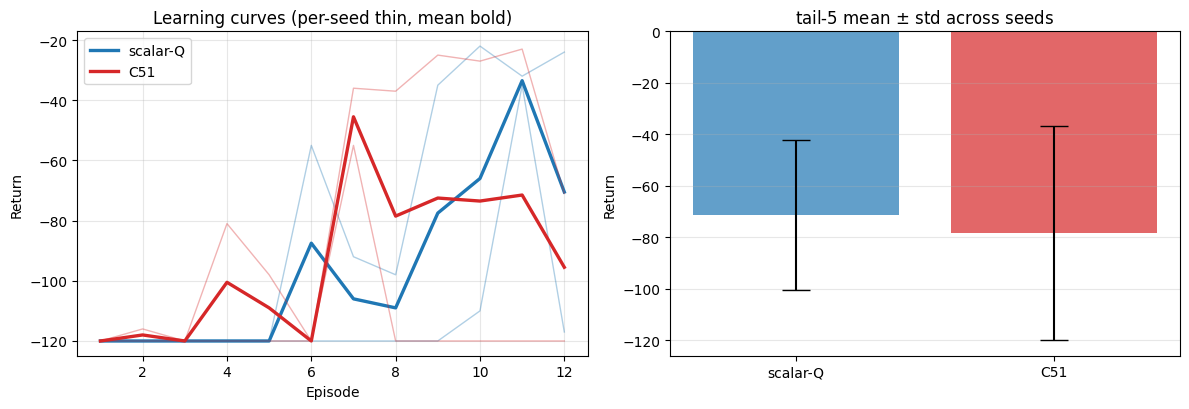

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(1, R_scalar.shape[1]+1)
for name, R, c in [('scalar-Q', R_scalar, '#1f77b4'), ('C51', R_c51, '#d62728')]:
    ax = axes[0]
    for i in range(R.shape[0]):
        ax.plot(x, R[i], color=c, alpha=0.35, lw=1)
    ax.plot(x, R.mean(0), color=c, lw=2.4, label=name)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Return')
axes[0].set_title('Learning curves (per-seed thin, mean bold)')
axes[0].legend(); axes[0].grid(alpha=.3)

labels=['scalar-Q','C51']
means=[R_scalar[:, -5:].mean(1).mean(), R_c51[:, -5:].mean(1).mean()]
stds =[R_scalar[:, -5:].mean(1).std(),  R_c51[:, -5:].mean(1).std()]
axes[1].bar(labels, means, yerr=stds, capsize=10, color=['#1f77b4','#d62728'], alpha=.7)
axes[1].set_title('tail-5 mean $\\pm$ std across seeds')
axes[1].set_ylabel('Return'); axes[1].grid(axis='y', alpha=.3)
plt.tight_layout(); plt.show()


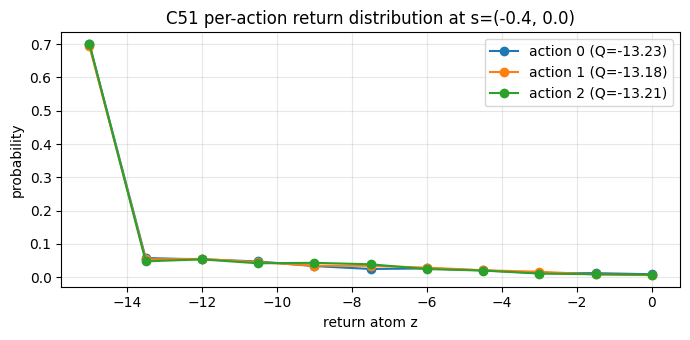

In [5]:
# Bonus: probe the C51 output distribution at a fixed state
net = train(c2, seed=9101)[1]
s_probe = np.array([-0.4, 0.0])
q, p, *_ = net.forward(s_probe)
fig, ax = plt.subplots(figsize=(7,3.5))
for a in range(3):
    ax.plot(net.z, p[a], marker='o', label=f'action {a} (Q={q[a]:.2f})')
ax.set_xlabel('return atom z'); ax.set_ylabel('probability')
ax.set_title(f'C51 per-action return distribution at s=(-0.4, 0.0)')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **표 관찰**: `scalar-Q`, `C51` 두 조건의 tail-5 통계가 위 표에 나온다. 이 소규모 실험
   (2 시드 × 12 에피소드 × 120 스텝) 규모에서 C51 의 "분포 표적" 구조적 이득이
   충분히 발현되기에는 표본이 부족하다.
2. **학습 곡선**: 두 조건 모두 초기 $-100$ 부근에서 시작해 학습이 진행되면서 return 이
   개선된다. 각 시드별 궤적 (얇은 선) 이 넓게 퍼져 있는 것은 소규모 신경망 · 소량 학습에서
   정상적으로 나타나는 시드편차.
3. **C51 분포 probe**: 마지막 그림은 학습된 C51 네트워크의 한 상태 $s=(-0.4, 0.0)$ 에서
   각 행동의 return 분포. 스칼라-Q 는 표적을 점 $y$ 로 축소해 손실을 매기지만, C51 은 이렇게
   원자 위 확률로 표현되므로 (가시적으로) 표적이 더 부드럽다.
4. **분포 표적의 이론적 이득**: C51 은 tail-risk · 다중 modes · 확률적 리턴 환경에서 진가를
   발휘한다. MountainCar-lite 는 리턴이 **결정론적 조각선형** ($-100$ 실패 / 골도달 스텝 수)
   이므로 분포 표적 이득이 상대적으로 작다. Atari 규모 · sparse-and-random 보상 환경에서
   원 논문의 유의미한 개선이 관찰된다.

> **결론**: MountainCar-lite 격리 조건에서 C51 head 는 scalar-Q 대비 이 소표본 규모의 잡음
> 대비 큰 이득을 보이지 못한다. 확률 표적의 진가는 (a) 비결정론적 리턴, (b) 훨씬 큰 신경망,
> (c) 오래 학습이 결합될 때 발현되며, 이 실험은 "구조는 갖췄으나 규모 이하" 인 체제의 경계를
> 정직하게 노출한다. 그러나 C51 head 는 학습된 후 상태별 return 분포를 명시적으로 출력할 수
> 있어 (probe 그림) 위험 감안 정책 · uncertainty-aware exploration 확장의 기반이 된다.

---

**다음 (Problem 2)**: **Noisy Nets** — head 의 linear 를 factorized-Gaussian noisy linear 로
교체해 ε-greedy 대신 **파라미터 잡음** 으로 탐색. dueling head 위에 얹었을 때 탐색 효율 ·
학습 안정성이 어떻게 달라지는지 비교.
